

### **Parameter Initialisation**



In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import utils

2026-04-14 19:25:47.381145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 19:25:47.475568: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 19:25:47.475950: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-14 19:25:47.600772: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-14 19:25:48.928928: W tensorflow/compiler/tf

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# data normalisation
mean = X_train.mean()
std  = X_train.std()
X_train = (X_train.astype('float32') - mean) / std
X_test  = (X_test.astype('float32')  - mean) / std

X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

##### a) **Implement a model for classifying Fashion-MNIST**
Use 5 hidden conv layers or fully connected layers with Tanh non-linearity. Use the defaults parameter initialisation

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='tanh', padding='same', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='tanh', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='tanh', padding='same'),
    layers.Conv2D(128, (3, 3), activation='tanh', padding='same'),
    layers.Conv2D(64, (3, 3), activation='tanh', padding='same'),

    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])
# if we apply more pooling we will obtain a picture which will be too small.

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345,418 (1.32 MB)

 Trainable params: 345,418 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

##### b) **Train the model**
Over 10 epochs by using Adam with default settings. Use input data normalisation.

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nAccuracy : {test_acc:.4f}")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.8514 - loss: 0.4203 - val_accuracy: 0.8802 - val_loss: 0.3320
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.8871 - loss: 0.3204 - val_accuracy: 0.8730 - val_loss: 0.3685
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.8991 - loss: 0.2882 - val_accuracy: 0.8925 - val_loss: 0.3181
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.9058 - loss: 0.2686 - val_accuracy: 0.8998 - val_loss: 0.3095
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9127 - loss: 0.2477 - val_accuracy: 0.8978 - val_loss: 0.3036
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9174 - loss: 0.2381 - val_accuracy: 0.9017 - val_loss: 0.3185
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9233 - loss: 0.2231 - val_accuracy: 0.8762 - val_loss: 0.3918
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9250 - loss: 0.2207 - 

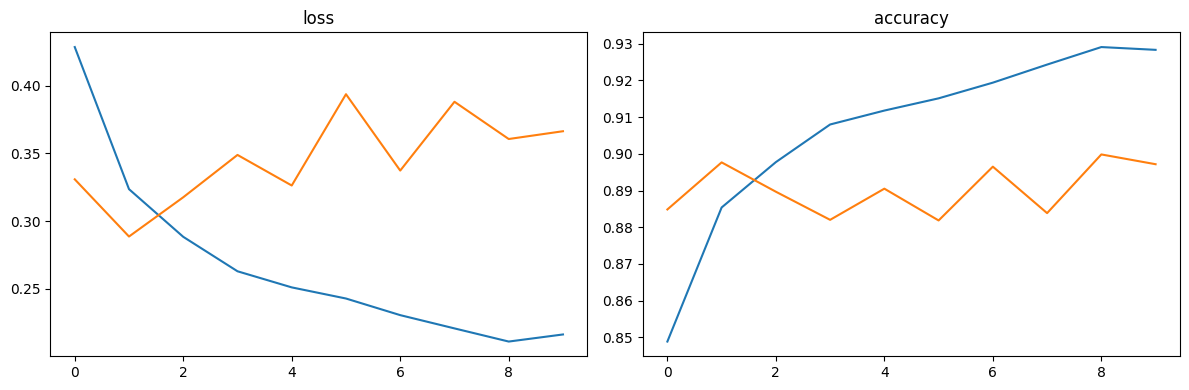

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('loss')
ax2.plot(history.history['accuracy'],     label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title("accuracy")
plt.tight_layout()
plt.show()

The blue line corresponds to  the training and the orange one to the validation.

##### c) **Change the weights and bias initialisers for MLP and CNN layers**

In Tensorflow/Keras, we can change the weights and bias initialiser both in Dense (MLP) and Conv2d (CNN) layers. Those layers have two parameters :
- ```kernel_initializer``` for the weights
- ```bias_initializer``` for the bias

The default values are ```glorot_uniform``` for the kernel and `zeros` for the bias. There are the initialisers used with our previous model.

 But we can also use `glorot_normal` (for Xavier initialisation), `he_normal` (recommended with ReLU), `he_uniform` (recommended for He), `random_normal` (normal centered in 0) or `ones`.


##### d) **Other initialisers**
Over 10 epochs
- **model_1** : zero weigth and zero bias
- **model_2** : standard normal weights and zero bias
- **model_3** : uniform(-0.5, 0.5) weights and zero bias
- **model_4** : Xavier Glorot initialization (for tanh) with zero bias.
- **model_5** : Kaiming He initialization (for ReLU) with zero bias

In [ ]:
model_1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='tanh', padding='same', input_shape=(28, 28, 1),
                  kernel_initializer='zeros',
                  bias_initializer='zeros'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='tanh', padding='same',
                  kernel_initializer='zeros',
                  bias_initializer='zeros'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='tanh', padding='same', kernel_initializer='zeros', bias_initializer='zeros'),
    layers.Conv2D(128, (3, 3), activation='tanh', padding='same', kernel_initializer='zeros', bias_initializer='zeros'),
    layers.Conv2D(64, (3, 3), activation='tanh', padding='same', kernel_initializer='zeros', bias_initializer='zeros'),

    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])
model_1.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_1 = model_1.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

/home/lena/.venvs/mon-venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.0992 - loss: 2.3035 - val_accuracy: 0.0985 - val_loss: 2.3032
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.1014 - loss: 2.3035 - val_accuracy: 0.0985 - val_loss: 2.3027
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.1011 - loss: 2.3035 - val_accuracy: 0.0942 - val_loss: 2.3028
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.0988 - loss: 2.3035 - val_accuracy: 0.1032 - val_loss: 2.3031
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.1012 - loss: 2.3033 - val_accuracy: 0.1003 - val_loss: 2.3034
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.1009 - loss: 2.3034 - val_accuracy: 0.0925 - val_loss: 2.3045
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.0996 - loss: 2.3034 - val_accuracy: 0.0985 - val_loss: 2.3037
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.1021 - loss: 2.3034 - 

In [ ]:
initializer = tf.keras.initializers.RandomNormal(mean=0.0, stddev=1.0)

model_2 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='tanh', padding='same', input_shape=(28, 28, 1),
                  kernel_initializer=initializer,
                  bias_initializer='zeros'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='tanh', padding='same',
                  kernel_initializer=initializer,
                  bias_initializer='zeros'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='tanh', padding='same', kernel_initializer=initializer, bias_initializer='zeros'),
    layers.Conv2D(128, (3, 3), activation='tanh', padding='same', kernel_initializer=initializer, bias_initializer='zeros'),
    layers.Conv2D(64, (3, 3), activation='tanh', padding='same', kernel_initializer=initializer, bias_initializer='zeros'),

    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])
model_2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_2 = model_2.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

/home/lena/.venvs/mon-venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.7776 - loss: 0.6494 - val_accuracy: 0.8090 - val_loss: 0.5643
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.8058 - loss: 0.5633 - val_accuracy: 0.8017 - val_loss: 0.5839
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.8066 - loss: 0.5695 - val_accuracy: 0.8040 - val_loss: 0.5802
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.8087 - loss: 0.5752 - val_accuracy: 0.8038 - val_loss: 0.5721
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8081 - loss: 0.5772 - val_accuracy: 0.8035 - val_loss: 0.6116
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.8074 - loss: 0.5738 - val_accuracy: 0.8015 - val_loss: 0.5842
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.8081 - loss: 0.5799 - val_accuracy: 0.8018 - val_loss: 0.5778
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8075 - loss: 0.5779 - 

In [ ]:
initializer = tf.keras.initializers.RandomUniform(-0.5, 0.5)

model_3 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='tanh', padding='same', input_shape=(28, 28, 1),
                  kernel_initializer=initializer,
                  bias_initializer='zeros'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='tanh', padding='same',
                  kernel_initializer=initializer,
                  bias_initializer='zeros'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='tanh', padding='same', kernel_initializer=initializer, bias_initializer='zeros'),
    layers.Conv2D(128, (3, 3), activation='tanh', padding='same', kernel_initializer=initializer, bias_initializer='zeros'),
    layers.Conv2D(64, (3, 3), activation='tanh', padding='same', kernel_initializer=initializer, bias_initializer='zeros'),

    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])
model_3.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_3 = model_3.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

/home/lena/.venvs/mon-venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 37ms/step - accuracy: 0.7948 - loss: 0.5954 - val_accuracy: 0.8102 - val_loss: 0.5808
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8180 - loss: 0.5320 - val_accuracy: 0.8110 - val_loss: 0.5437
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.8264 - loss: 0.5111 - val_accuracy: 0.7973 - val_loss: 0.5996
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.8306 - loss: 0.5068 - val_accuracy: 0.8292 - val_loss: 0.5060
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.8402 - loss: 0.4795 - val_accuracy: 0.8420 - val_loss: 0.4702
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.8377 - loss: 0.4860 - val_accuracy: 0.8458 - val_loss: 0.4573
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.8413 - loss: 0.4724 - val_accuracy: 0.8460 - val_loss: 0.4590
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.8461 - loss: 0.4630 - 

In [ ]:
model_4 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='tanh', padding='same', input_shape=(28, 28, 1),
                  kernel_initializer='glorot_normal',
                  bias_initializer='zeros'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='tanh', padding='same',
                  kernel_initializer='glorot_normal',
                  bias_initializer='zeros'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='tanh', padding='same', kernel_initializer='glorot_normal', bias_initializer='zeros'),
    layers.Conv2D(128, (3, 3), activation='tanh', padding='same', kernel_initializer='glorot_normal', bias_initializer='zeros'),
    layers.Conv2D(64, (3, 3), activation='tanh', padding='same', kernel_initializer='glorot_normal', bias_initializer='zeros'),

    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])
model_4.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_4 = model_4.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.8490 - loss: 0.4284 - val_accuracy: 0.8788 - val_loss: 0.3420
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8876 - loss: 0.3194 - val_accuracy: 0.8633 - val_loss: 0.3874
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8983 - loss: 0.2871 - val_accuracy: 0.8915 - val_loss: 0.3200
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.9046 - loss: 0.2665 - val_accuracy: 0.8870 - val_loss: 0.3356
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9111 - loss: 0.2521 - val_accuracy: 0.8890 - val_loss: 0.3230
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9156 - loss: 0.2366 - val_accuracy: 0.9017 - val_loss: 0.3047
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9206 - loss: 0.2255 - val_accuracy: 0.8895 - val_loss: 0.3492
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9246 - loss: 0.2173 - 

In [ ]:
model_5 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1),
                  kernel_initializer='he_normal',
                  bias_initializer='zeros'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                  kernel_initializer='he_normal',
                  bias_initializer='zeros'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal', bias_initializer='zeros'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal', bias_initializer='zeros'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal', bias_initializer='zeros'),

    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])
model_5.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_5 = model_5.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

Epoch 1/10


/home/lena/.venvs/mon-venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 31ms/step - accuracy: 0.8482 - loss: 0.4243 - val_accuracy: 0.8842 - val_loss: 0.3174
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.8977 - loss: 0.2797 - val_accuracy: 0.8978 - val_loss: 0.2847
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9165 - loss: 0.2327 - val_accuracy: 0.9075 - val_loss: 0.2593
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9238 - loss: 0.2045 - val_accuracy: 0.9135 - val_loss: 0.2334
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9351 - loss: 0.1771 - val_accuracy: 0.9192 - val_loss: 0.2319
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9431 - loss: 0.1554 - val_accuracy: 0.9117 - val_loss: 0.2426
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9492 - loss: 0.1356 - val_accuracy: 0.9188 - val_loss: 0.2383
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9562 - loss: 0.1176 - val_accurac

##### e) **Comparaison plot and analyze the results**
Are they expected from the theory that you have learned in class ?

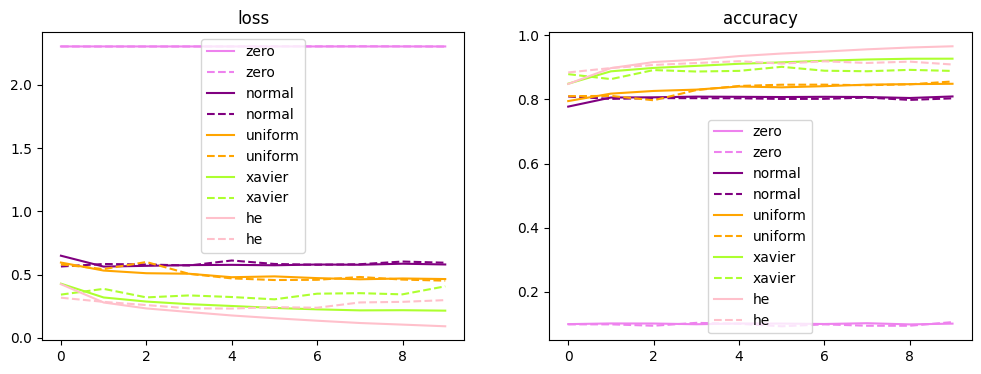

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_1.history['loss'],     label='zero', linestyle = '-', c = 'violet')
ax1.plot(history_1.history['val_loss'], label='zero', linestyle = '--', c = 'violet')
ax1.plot(history_2.history['loss'],     label='normal',linestyle = '-', c = 'purple')
ax1.plot(history_2.history['val_loss'], label='normal', linestyle = '--', c= 'purple')
ax1.plot(history_3.history['loss'],     label='uniform',linestyle = '-', c = 'orange')
ax1.plot(history_3.history['val_loss'], label='uniform', linestyle = '--', c = 'orange')
ax1.plot(history_4.history['loss'],     label='xavier', linestyle = '-', c = 'greenyellow')
ax1.plot(history_4.history['val_loss'], label='xavier', linestyle = '--', c = 'greenyellow')
ax1.plot(history_5.history['loss'],     label='he', linestyle = '-', c = 'pink')
ax1.plot(history_5.history['val_loss'], label='he', linestyle = '--', c = 'pink')
ax1.legend()
ax1.set_title('loss')

ax2.plot(history_1.history['accuracy'],     label='zero', linestyle = '-', c = 'violet')
ax2.plot(history_1.history['val_accuracy'], label='zero', linestyle = '--', c = 'violet')
ax2.plot(history_2.history['accuracy'],     label='normal',linestyle = '-', c = 'purple')
ax2.plot(history_2.history['val_accuracy'], label='normal', linestyle = '--', c= 'purple')
ax2.plot(history_3.history['accuracy'],     label='uniform',linestyle = '-', c = 'orange')
ax2.plot(history_3.history['val_accuracy'], label='uniform', linestyle = '--', c = 'orange')
ax2.plot(history_4.history['accuracy'],     label='xavier', linestyle = '-', c = 'greenyellow')
ax2.plot(history_4.history['val_accuracy'], label='xavier', linestyle = '--', c = 'greenyellow')
ax2.plot(history_5.history['accuracy'],     label='he', linestyle = '-', c = 'pink')
ax2.plot(history_5.history['val_accuracy'], label='he', linestyle = '--', c = 'pink')
ax2.legend()
ax2.set_title("accuracy")
plt.show()

- <span style='color: violet;'>Model_1 : zero</span> : Fails completely. Loss stays flat, which means that there is random chance for 10 classes, and accuracy is stuck at ~10%. This is the symetry problem where all neurons receive identical gradients, so the network can't learn.

- <span style='color: purple;'>Model2 : normal</span> : The stddev=1.0 is too big for the network with tanh() as our activation function. This function will fastly saturate around -1 and 1. The problem of the **vanishing gradient** appears : gradient tends to 0 and the network is no longer able to learn.

- <span style='color: orange;'>Model_3 : uniform</span>  Slightly better than normal.

- <span style='color: greenyellow;'>Model_4 : xavier</span> Good performance with a low loss and a high accuracy (~90%+). Xavier is designed for sigmoid/tanh activations avoiding the problem of the vanishing gradient.

- <span style='color: pink;'>Model_5 : he </span> Best performance among the other models. He initialization is specifically designed for ReLU activations.


##### **Conclusion**
Initialization matters to reach good accuracy thanks to a wise choice of parameters. On every model we tried, the train/val gap stays small, suggesting no major overfitting. The major difference is driven by the initilization strategy that is applied and how well gradients flow from the start.